# Streaming a transfer larger than the card

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FiRMLAB-Pisa/mrtoeplitz/blob/main/examples/streaming.ipynb)

`CudaStreaming`: staging a transfer in pinned host memory and bringing it
over in chunks, so a transfer that does not fit stays exact instead of
dropping to a slower lane.

In [1]:
try:
    import mrtoeplitz  # noqa: F401
except ImportError:
    %pip install -q "mrtoeplitz[cuda]" matplotlib finufft

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

import mrtoeplitz as mt


def phantom(n=128):
    """A Shepp-Logan phantom on an n x n grid."""
    y, x = np.mgrid[-1 : 1 : n * 1j, -1 : 1 : n * 1j]
    ellipses = [
        # value, centre x, centre y, semi-axis a, semi-axis b, degrees
        (1.0, 0.0, 0.0, 0.69, 0.92, 0),
        (-0.8, 0.0, -0.0184, 0.6624, 0.874, 0),
        (-0.2, 0.22, 0.0, 0.11, 0.31, -18),
        (-0.2, -0.22, 0.0, 0.16, 0.41, 18),
        (0.1, 0.0, 0.35, 0.21, 0.25, 0),
        (0.1, 0.0, 0.1, 0.046, 0.046, 0),
        (0.1, 0.0, -0.1, 0.046, 0.046, 0),
        (0.1, -0.08, -0.605, 0.046, 0.023, 0),
        (0.1, 0.0, -0.606, 0.023, 0.023, 0),
        (0.1, 0.06, -0.605, 0.023, 0.046, 0),
    ]
    image = np.zeros((n, n))
    for value, cx, cy, a, b, degrees in ellipses:
        angle = np.deg2rad(degrees)
        xr = (x - cx) * np.cos(angle) + (y - cy) * np.sin(angle)
        yr = -(x - cx) * np.sin(angle) + (y - cy) * np.cos(angle)
        image[(xr / a) ** 2 + (yr / b) ** 2 <= 1.0] += value
    return image


available = torch.cuda.is_available()
print("CUDA device present" if available else "no CUDA device; the last cell explains")

n = 96
image = torch.as_tensor(phantom(n)).to(torch.complex64)[None, None]
angles = np.linspace(0, np.pi, 128, endpoint=False)
radius = np.linspace(-0.5, 0.5, 192, endpoint=False)
trajectory = np.stack(
    [np.outer(np.cos(angles), radius), np.outer(np.sin(angles), radius)], axis=-1
).astype(np.float32)
density = np.linalg.norm(trajectory, axis=-1).astype(np.float32)

CUDA device present


## A transfer that will not fit

A compressed transfer for a high-resolution subspace reconstruction can be
larger than the card. Rather than dropping to a slower lane, it stays in
pinned host memory and arrives in chunks, with the copy of one chunk
overlapping the multiply of the one before.

The policy is given when the kernel is built, because the builder has to stage
the transfer on the host to begin with. Calling the kernel then streams, and
the call is differentiable exactly as the resident one is.

In [3]:
# The policy is a property of the transfer -- the builder has to stage it on
# the host to begin with -- so it is given once, and calling the kernel streams.
policy = mt.CudaStreaming(streams=2, transfer_precision="float32")
print(policy)

resident = mt.scalar_kernel(trajectory, (n, n), density=density)
streamed = mt.scalar_kernel(trajectory, (n, n), density=density, streaming=policy)

# A resident kernel is moved to the card and its transfer goes with it. A
# streamed one has nowhere to be moved to: the transfer stays on the host and
# the call brings it over in chunks.
print(f"\nresident, after .to('cuda'): transfer on "
      f"{resident.to('cuda').values.device}")
print(f"streamed, as built:          transfer on {streamed.values.device}")
print(f"the policy rides on the kernel: {streamed.streaming is policy}")

CudaStreaming(device='cuda', devices=None, streams=2, pin_memory=True, transfer_chunk_size=1048576, physics_batch_size=1, kernel_residency='auto', transfer_precision='float32', max_device_fraction=0.85)



resident, after .to('cuda'): transfer on cuda:0
streamed, as built:          transfer on cpu
the policy rides on the kernel: True


## The same operator

Streaming changes where the transfer is, not what it computes.

In [4]:
truth = resident(image)

if available:
    got = streamed(image)
    error = float((got.cpu() - truth).norm() / truth.norm())
    print(f"streamed and resident agree to {error:.1e}")
else:
    got, error = truth, float("nan")
    print("skipped: streaming needs a CUDA device")

streamed and resident agree to 2.2e-07


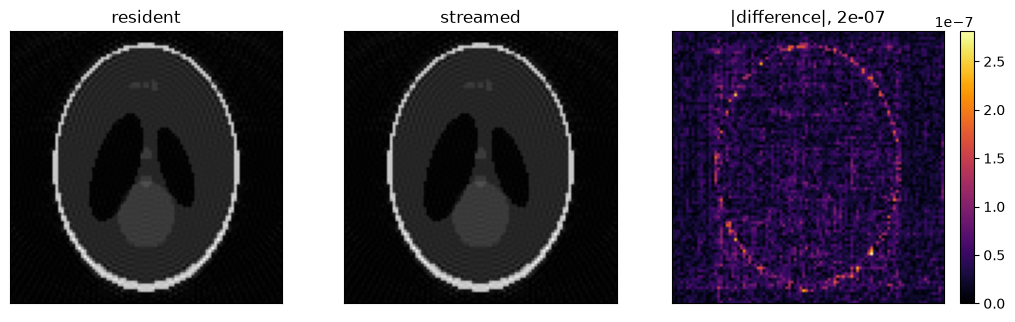

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.2))
axes[0].imshow(np.abs(truth[0, 0].numpy()), cmap="gray")
axes[0].set_title("resident")
axes[1].imshow(np.abs(np.asarray(got.cpu()[0, 0])), cmap="gray")
axes[1].set_title("streamed" if available else "streamed (no device)")
for axis in axes[:2]:
    axis.set_xticks([])
    axis.set_yticks([])
difference = np.abs(np.asarray(got.cpu()[0, 0]) - truth[0, 0].numpy())
shown = axes[2].imshow(difference / np.abs(truth.numpy()).max(), cmap="inferno")
axes[2].set_title(f"|difference|, {error:.0e}" if available else "no device")
axes[2].set_xticks([])
axes[2].set_yticks([])
fig.colorbar(shown, ax=axes[2], fraction=0.046)
fig.tight_layout()

In [6]:
# Written only when the notebook runs inside a clone, and it is what the
# README shows -- so the figure in the README is always this cell's output.
figures = Path("figures")
if figures.is_dir():
    fig.savefig(figures / "streaming.png", dpi=110, bbox_inches="tight")

## What the device holds

The transfer here is small enough to be resident, which is what makes the
comparison runnable at all. The number to watch is not the ratio — at this
size it is small — but that the streamed peak does not contain the transfer.

In [7]:
if available:
    on_card = resident.to("cuda")
    x = image.cuda()

    # Both lanes are warmed first. The first apply of either compiles and
    # autotunes its Triton kernels, which allocates hundreds of megabytes and
    # has nothing to do with the transfer -- measuring it would report that
    # compilation as the cost of the lane.
    _ = streamed(image)
    _ = on_card(x)

    def peak(call):
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        call()
        return torch.cuda.max_memory_allocated() / 2**20

    streamed_peak = peak(lambda: streamed(image))
    resident_peak = peak(lambda: on_card(x))

    print(f"transfer itself:        {resident.storage_nbytes / 2**20:7.2f} MiB")
    print(f"device peak, resident:  {resident_peak:7.2f} MiB")
    print(f"device peak, streamed:  {streamed_peak:7.2f} MiB")
    print()
    print("At this size the transfer is small enough that both fit easily; what")
    print("the streamed lane changes is that the transfer is never resident, so")
    print("the peak stops following the transfer's size at all.")
    del on_card, x
    torch.cuda.empty_cache()
else:
    print("skipped: needs a CUDA device")

transfer itself:           0.24 MiB
device peak, resident:     1.45 MiB
device peak, streamed:     1.31 MiB

At this size the transfer is small enough that both fit easily; what
the streamed lane changes is that the transfer is never resident, so
the peak stops following the transfer's size at all.


## Narrowing the transfer

A streamed transfer is encoded in bfloat16 on a device that supports it, which
halves both what the host holds and what crosses the bus.

In [8]:
def device_transfer_bytes(built):
    """Bytes one full copy of the transfer occupies on the card.

    The cache holds chunks, and how many of them there are follows the chunk
    size rather than the precision, so summing the cache compares the wrong
    thing. What the encoding changes is the width of an entry.
    """
    total = 0
    for _, component in built.components:
        cached = next(iter(component._cuda_value_cache.values()), None)
        if cached is None:
            continue
        total += component.values.numel() * cached.element_size()
    return total


if available:
    print(f"{'precision':>12}  {'error':>9}  {'on the card':>12}")
    for choice in ("float32", "bfloat16"):
        narrow = mt.scalar_kernel(
            trajectory,
            (n, n),
            density=density,
            streaming=mt.CudaStreaming(streams=2, transfer_precision=choice),
        )
        deviation = float((narrow(image).cpu() - truth).norm() / truth.norm())
        print(f"{choice:>12}  {deviation:9.1e}  "
              f"{device_transfer_bytes(narrow) / 2**10:9.1f} KiB")
    print()
    print("bfloat16 is the default on a device that has it. It halves what the")
    print("card holds and what crosses the bus -- the host copy stays float32,")
    print("because that is what the builder produced -- for about two decimal")
    print("digits, which a transfer cut to its support and then summed over a")
    print("solve does not miss.")
else:
    print("skipped: needs a CUDA device")

   precision      error   on the card
     float32    2.2e-07      123.1 KiB
    bfloat16    1.0e-03       61.6 KiB

bfloat16 is the default on a device that has it. It halves what the
card holds and what crosses the bus -- the host copy stays float32,
because that is what the builder produced -- for about two decimal
digits, which a transfer cut to its support and then summed over a
solve does not miss.


## Without a CUDA device

`CudaStreaming` describes where a transfer is staged for a device that will
consume it, so there is nothing for it to do on a host-only machine. Build the
kernel without a policy and it stays resident, which is what every other
example here does.